In [5]:
import torch
import sys
print("Interpreter:", sys.executable)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Interpreter: d:\maga25\VKRTimeSeries\.venv\Scripts\python.exe
CUDA available: True
GPU name: NVIDIA GeForce GTX 1660


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")
if device.type == 'cuda':
    print(f"Видеокарта: {torch.cuda.get_device_name(0)}")
    print(f"Всего видеопамяти: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Используемое устройство: cuda
Видеокарта: NVIDIA GeForce GTX 1660
Всего видеопамяти: 6.44 GB


In [7]:
import random

import numpy as np
import pandas as pd
import torch

from transformers import (
    EarlyStoppingCallback,
    PatchTSTConfig,
    PatchTSTForPrediction,
    Trainer,
    TrainingArguments,
)

from tsfm_public.toolkit.dataset import ForecastDFDataset
from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor
from tsfm_public.toolkit.util import select_by_index

In [8]:
# воспроизводимость
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [11]:
import os
import numpy as np
import pandas as pd
import torch
from transformers import PatchTSTConfig, PatchTSTForPrediction
from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor
from tsfm_public.toolkit.dataset import ForecastDFDataset
from tsfm_public.toolkit.util import select_by_index
from sklearn.metrics import mean_squared_error


dataset = "data/weather.csv"

num_workers = 6 # кол-во потоков для загрузки данных
batch_size = 32 # кол-во одновременно обрабатываемых образцов данных
context_length = 168 # длина окна
forecast_horizon = 96 # длина предсказания
patch_length = 12 # размер патча (число временных шагов по всем признакам)
pin_memory = True
fp16 = True

timestamp_column = "date"
id_columns = []

train_start_index = None
train_end_index = 9 * 30 * 24 # в обучении 9 месяцев данных (9мес * 30дн * 24ч * 6мин)

# индекс начала валидации сдвинут на context_length, чтобы оценить прогноз с начала валидационных данных
valid_start_index = 9 * 30 * 24 - context_length
valid_end_index = 9 * 30 * 24 + 1 * 30 * 24

# индекс начала теста сдвинут на context_length, чтобы оценить прогноз с начала тестовых данных
test_start_index = 9 * 30 * 24 + 1 * 30 * 24 - context_length
test_end_index = 9 * 30 * 24 + 3 * 30 * 24


# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
data = pd.read_csv(
    dataset,
    parse_dates=[timestamp_column], # тип date -> datetime
)
data.set_index(timestamp_column, inplace=True)

# Ресемплинг на 1 час (среднее)
# Используем '1h' вместо '1H' для совместимости
try:
    data = data.resample('1h').mean().dropna()
except ValueError:
    data = data.resample('60T').mean().dropna()  # альтернативный вариант

data.reset_index(inplace=True)

print(len(data))

# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

forecast_columns = [col for col in data.columns if col != 'date']

train_data = select_by_index(
    data,
    id_columns=id_columns,
    start_index=train_start_index,
    end_index=train_end_index,
)
valid_data = select_by_index(
    data,
    id_columns=id_columns,
    start_index=valid_start_index,
    end_index=valid_end_index,
)
test_data = select_by_index(
    data,
    id_columns=id_columns,
    start_index=test_start_index,
    end_index=test_end_index,
)

tsp_weather = TimeSeriesPreprocessor(
    timestamp_column=timestamp_column,
    id_columns=id_columns,
    target_columns=forecast_columns,
    scaling=True,
)
tsp_weather.train(train_data) # вычисление среднего и дисперсии


train_dataset = ForecastDFDataset(
    tsp_weather.preprocess(train_data),
    id_columns=id_columns,
    target_columns=forecast_columns,
    context_length=context_length,
    prediction_length=forecast_horizon,
    stride=1
)
valid_dataset = ForecastDFDataset(
    tsp_weather.preprocess(valid_data),
    id_columns=id_columns,
    target_columns=forecast_columns,
    context_length=context_length,
    prediction_length=forecast_horizon,
    stride=1
)
test_dataset = ForecastDFDataset(
    tsp_weather.preprocess(test_data),
    id_columns=id_columns,
    target_columns=forecast_columns,
    context_length=context_length,
    prediction_length=forecast_horizon,
    stride=1
)



weather_model_path = "./best_patchtst_weather_etth1_model"
# Загружаем конфигурацию дообученной модели
old_config = PatchTSTConfig.from_pretrained(weather_model_path)

# Создаём новую конфигурацию для 7 каналов ETTh1
new_config_etth1 = PatchTSTConfig(
    num_input_channels=len(forecast_columns),   # 7
    context_length=context_length,
    patch_length=patch_length,
    prediction_length=forecast_horizon,
    patch_stride=old_config.patch_length, 
    d_model=old_config.d_model,
    num_attention_heads=old_config.num_attention_heads,
    num_hidden_layers=old_config.num_hidden_layers,
    ffn_dim=old_config.ffn_dim,
    dropout=old_config.dropout,
    head_dropout=old_config.head_dropout,
    pooling_type=old_config.pooling_type,
    channel_attention=old_config.channel_attention,
    scaling=old_config.scaling,
    loss=old_config.loss,
    pre_norm=old_config.pre_norm,
    norm_type=old_config.norm_type,
    do_mask_input=False   # при тестировании маскировка не нужна
)

# Загружаем модель, игнорируя несовместимости размеров (входной слой)
model_adapted = PatchTSTForPrediction.from_pretrained(
    weather_model_path,
    config=new_config_etth1,
    ignore_mismatched_sizes=True,
    device_map='cpu'        # можно оставить 'cuda' если есть GPU
)
model_adapted.eval()
print("✅ Модель загружена и адаптирована для 7 каналов ETTh1")

# ============================================================
# 5. Прямой forward на всех тестовых примерах
# ============================================================
all_preds = []
all_labels = []

with torch.no_grad():
    for i in range(len(test_dataset)):
        sample = test_dataset[i]
        past = sample['past_values'].unsqueeze(0)  # (1, context_length, 7)
        output = model_adapted(past_values=past)
        if hasattr(output, 'prediction_outputs'):
            pred = output.prediction_outputs.squeeze(0).cpu().numpy()
        elif hasattr(output, 'logits'):
            pred = output.logits.squeeze(0).cpu().numpy()
        else:
            raise ValueError("Нет prediction_outputs или logits")
        all_preds.append(pred)
        all_labels.append(sample['future_values'].numpy())

all_preds = np.array(all_preds)   # (num_samples, 96, 7)
all_labels = np.array(all_labels)
print(f"all_preds.shape: {all_preds.shape}")
print(f"all_labels.shape: {all_labels.shape}")

# ============================================================
# 6. MSE в нормированном пространстве
# ============================================================
mse_norm = np.mean((all_preds - all_labels) ** 2)
print(f"Test loss на ETTh1 (MSE в нормированном пространстве): {mse_norm:.4f}")

# ============================================================
# 7. RMSE для OT в исходных единицах
# ============================================================
ot_idx = forecast_columns.index('OT')

# Берём общий скалер (он один, ключ '0')
scaler = list(tsp_weather.target_scaler_dict.values())[0]

# Преобразуем все предсказания и истинные значения к плоскому виду (все временные шаги)
all_true_flat = all_labels.reshape(-1, len(forecast_columns))   # (total_time_steps, 7)
all_pred_flat = all_preds.reshape(-1, len(forecast_columns))

# Инвертируем масштабирование для всех признаков
true_inv = scaler.inverse_transform(all_true_flat)
pred_inv = scaler.inverse_transform(all_pred_flat)

# Извлекаем столбец OT
true_ot_inv = true_inv[:, ot_idx].reshape(-1, 1)
pred_ot_inv = pred_inv[:, ot_idx].reshape(-1, 1)

rmse_ot = np.sqrt(mean_squared_error(true_ot_inv, pred_ot_inv))
print(f"RMSE для OT (в исходных единицах, градусы): {rmse_ot:.4f}")

print("✅ Оценка завершена.")


8784


Loading weights: 100%|██████████| 71/71 [00:00<00:00, 6430.06it/s]
[transformers] PatchTSTForPrediction LOAD REPORT from: ./best_patchtst_weather_etth1_model
Key                                           | Status   |                                                                                           
----------------------------------------------+----------+-------------------------------------------------------------------------------------------
model.encoder.positional_encoder.position_enc | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([42, 128]) vs model:torch.Size([14, 128])  
head.projection.weight                        | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([96, 5376]) vs model:torch.Size([96, 1792])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Модель загружена и адаптирована для 7 каналов ETTh1
all_preds.shape: (1345, 96, 21)
all_labels.shape: (1345, 96, 21)
Test loss на ETTh1 (MSE в нормированном пространстве): 0.3393
RMSE для OT (в исходных единицах, градусы): 18.9277
✅ Оценка завершена.


In [10]:
# лучшая модель (stride=1)
model.save_pretrained("./best_patchtst_weather_etth1_model")
tsp.save_pretrained("./best_tsp_weather_etth1_preprocessor")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 84.27it/s]
INFO:p-25256:t-28636:processor.py:save_pretrained:Feature extractor saved in ./best_tsp_weather_etth1_preprocessor\preprocessor_config.json


['./best_tsp_weather_etth1_preprocessor\\preprocessor_config.json']

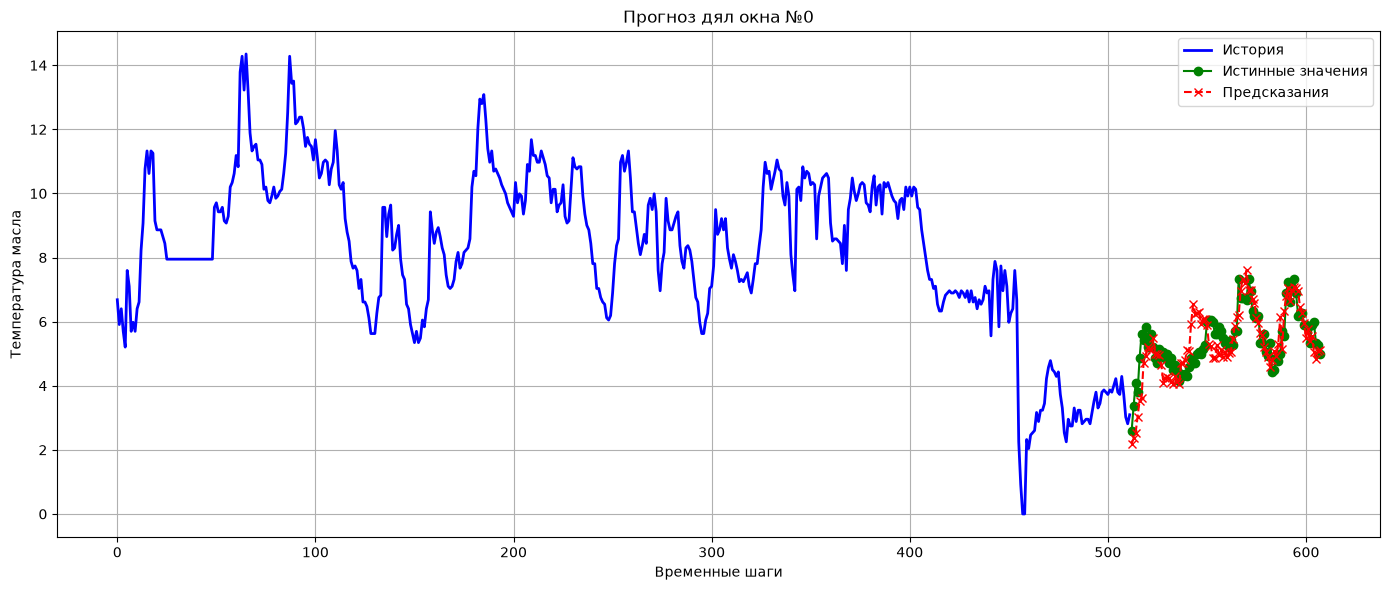

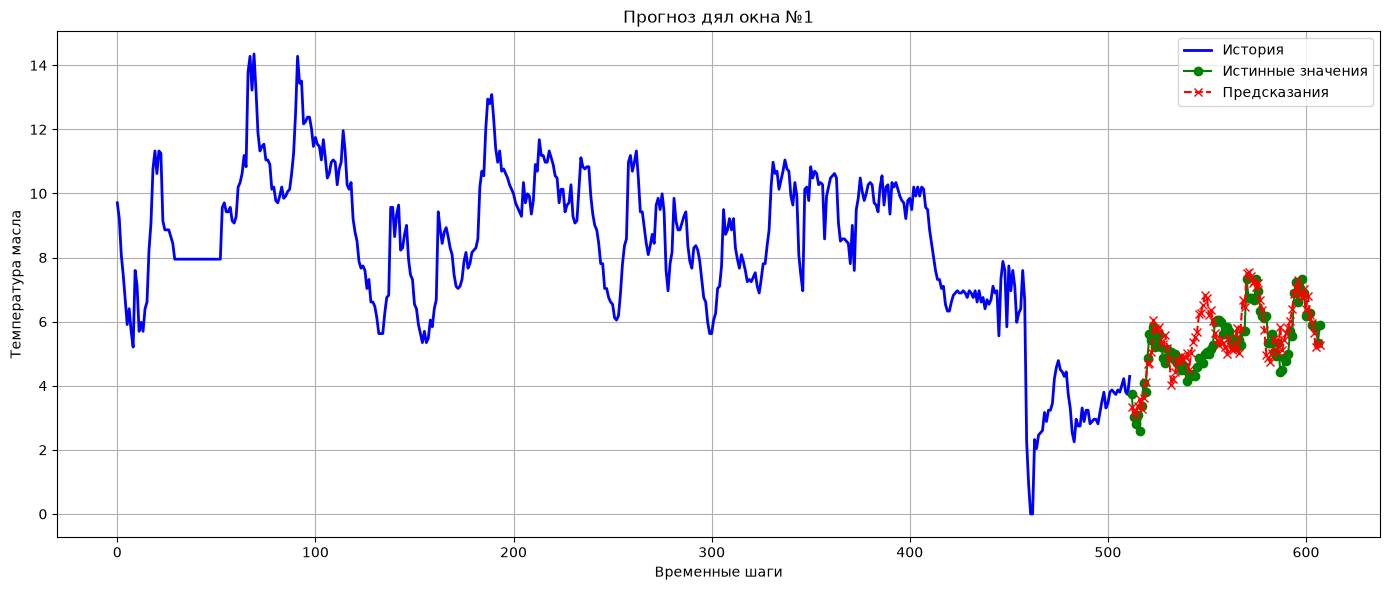

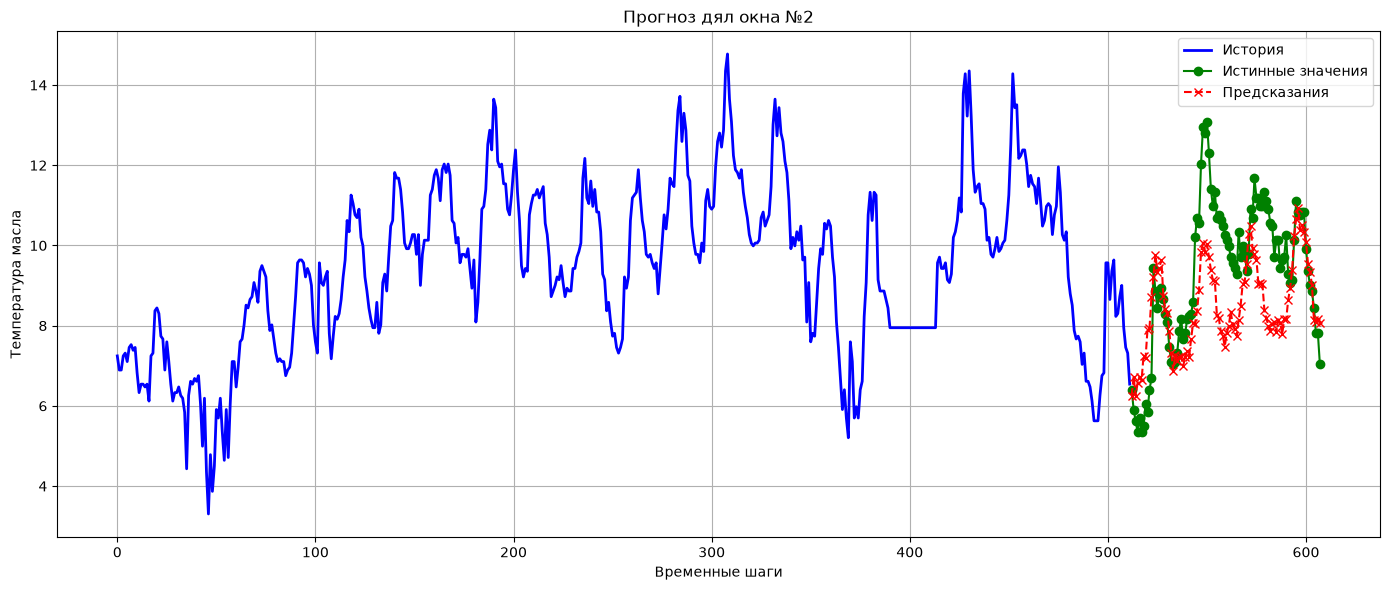

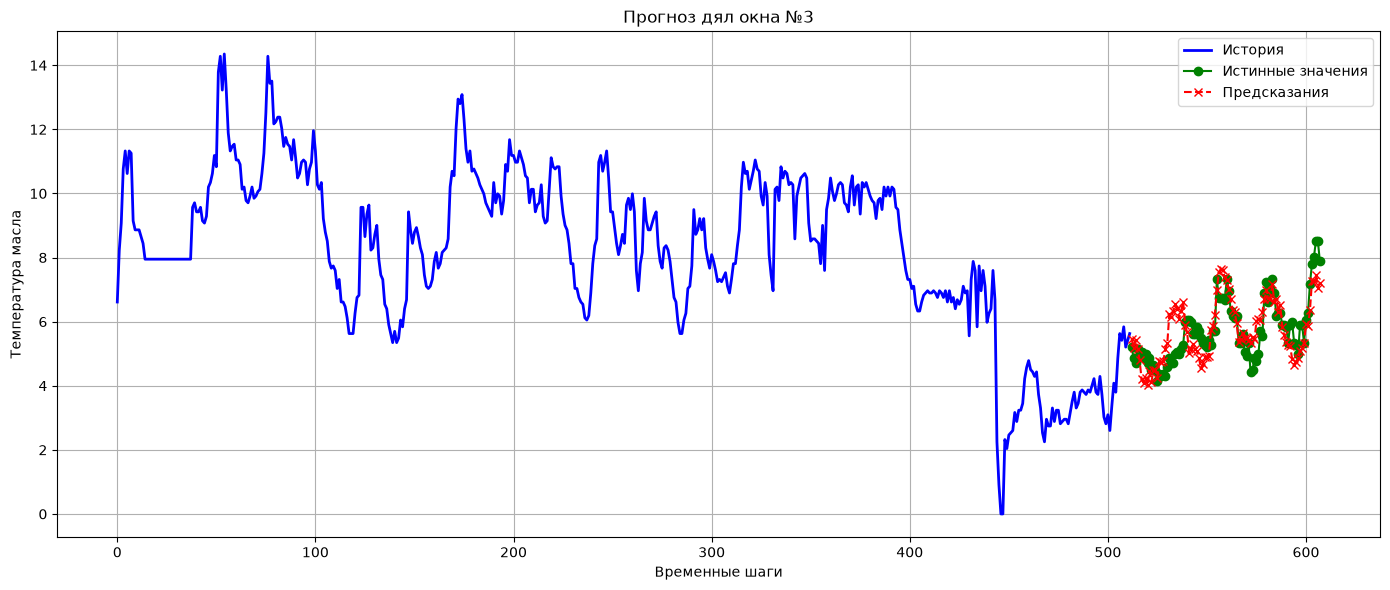

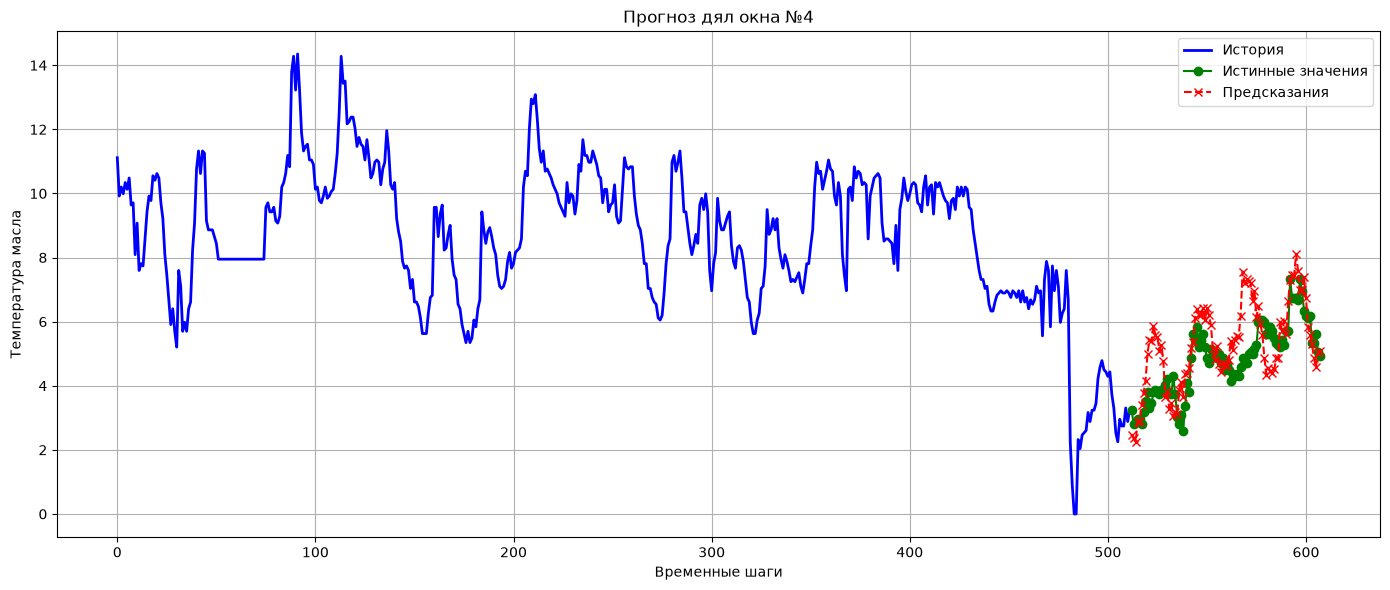

Метрика MSE:  4.5464
Метрика RMSE: 2.1322


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import mean_squared_error

# предсказания на тестовой выборке
test_results = trainer.predict(test_dataset)
preds = test_results.predictions

if isinstance(preds, tuple):
    preds = preds[0]

# объект для преобразования нормированных значений в исходные
scaler = list(tsp.target_scaler_dict.values())[0]

# преобразование в numpy
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.numpy()
    return np.array(x)


col_name = "OT"
col_idx = forecast_columns.index(col_name)

# визуализация
for num, idx in enumerate([655, 651, 290, 666, 629]):

    sample = test_dataset[idx] # выделение конкретного окна
    context = to_numpy(sample['past_values']) # исторические данные (context_length, num_features)
    true_future = to_numpy(sample['future_values']) # будущие истинные данные (forecast_horizon, num_features)
    pred_future = preds[idx] # будущие предсказания (forecast_horizon, num_features)

    # обратное масштабирования
    context_inv = scaler.inverse_transform(context)
    true_inv = scaler.inverse_transform(true_future)
    pred_inv = scaler.inverse_transform(pred_future)

    plt.figure(figsize=(14, 6))

    x_context = np.arange(context_length)
    x_future = np.arange(context_length, context_length + forecast_horizon)

    plt.plot(x_context, context_inv[:, col_idx], label='История', color='blue', linewidth=2)
    plt.plot(x_future, true_inv[:, col_idx], label='Истинные значения', color='green', marker='o', linestyle='-', linewidth=1.5)
    plt.plot(x_future, pred_inv[:, col_idx], label='Предсказания', color='red', marker='x', linestyle='--', linewidth=1.5)

    plt.xlabel('Временные шаги')
    plt.ylabel('Температура масла')
    plt.title(f'Прогноз дял окна №{num}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# оценка точности на тестовых данных

all_true = []
all_pred = []

for i in range(len(test_dataset)):
    sample_i = test_dataset[i]
    true_i = to_numpy(sample_i['future_values']).reshape(-1, len(forecast_columns))
    pred_i = preds[i].reshape(-1, len(forecast_columns))
    
    all_true.append(true_i)
    all_pred.append(pred_i)

all_true = np.vstack(all_true)   
all_pred = np.vstack(all_pred)

all_true_inv = scaler.inverse_transform(all_true)
all_pred_inv = scaler.inverse_transform(all_pred)

mse = mean_squared_error(all_true_inv[:, col_idx], all_pred_inv[:, col_idx])
rmse = np.sqrt(mse)

print(f"Метрика MSE:  {mse:.4f}")
print(f"Метрика RMSE: {rmse:.4f}")